In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Environment is ready!")

Python: C:\Users\l2e\Projects\phishing-message-classifier\.venv\Scripts\python.exe
Pandas: 3.0.5
NumPy: 2.5.2
Environment is ready!


# Phishing Message Classifier

## Dataset Exploration

This notebook is used to inspect, understand, and prepare the dataset for the phishing message classification project.

### Objectives

- Understand the dataset structure
- Inspect the available features
- Identify the target label
- Check missing values
- Check duplicate records
- Analyze class distribution
- Explore message characteristics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/raw/SMSSpamCollection"

print(file_path)

../data/raw/SMSSpamCollection


In [3]:
df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

In [6]:
df.columns

Index(['label', 'message'], dtype='str')

In [7]:
df.dtypes

label      str
message    str
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df["label"].unique()

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

In [12]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [13]:
df["label"].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

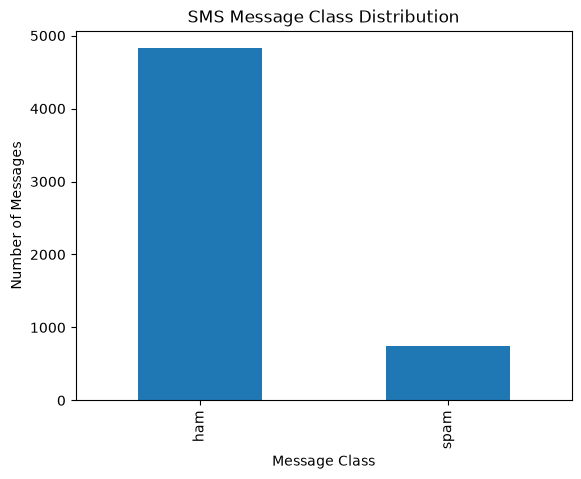

In [14]:
df["label"].value_counts().plot(kind="bar")

plt.title("SMS Message Class Distribution")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")

plt.show()

In [15]:
df[df["label"] == "ham"].head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
10,ham,I'm gonna be home soon and i don't want to tal...
13,ham,I've been searching for the right words to tha...
14,ham,I HAVE A DATE ON SUNDAY WITH WILL!!
16,ham,Oh k...i'm watching here:)


In [16]:
df[df["label"] == "spam"].head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
19,spam,England v Macedonia - dont miss the goals/team...
34,spam,Thanks for your subscription to Ringtone UK yo...
42,spam,07732584351 - Rodger Burns - MSG = We tried to...


In [17]:
df["message_length"] = df["message"].str.len()

In [18]:
df[["message", "message_length"]].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


In [19]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


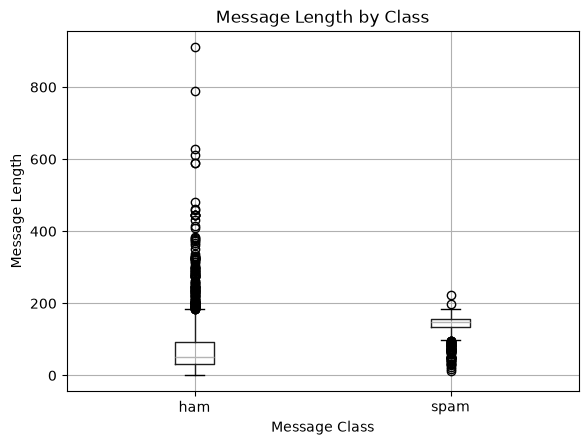

In [20]:
df.boxplot(column="message_length", by="label")

plt.title("Message Length by Class")
plt.suptitle("")
plt.xlabel("Message Class")
plt.ylabel("Message Length")

plt.show()

## Initial Dataset Findings

### Dataset Structure

The dataset contains labeled SMS messages for binary text classification.

### Features

- `message` — the raw SMS text.
- `message_length` — a derived feature representing the number of characters in the message.

### Target

- `label` — the message class.
- `ham` represents legitimate messages.
- `spam` represents spam messages.

### Data Quality

We checked:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Unique labels

### Class Distribution

The dataset contains significantly more legitimate messages than spam messages. Therefore, the dataset is imbalanced.

### Initial Hypothesis

Some characteristics such as message length and linguistic patterns may differ between legitimate and spam messages. However, these observations must be evaluated using appropriate machine-learning methods rather than assumed to be predictive.

In [21]:
clean_df = df.copy()

print("Original shape:", df.shape)
print("Working shape:", clean_df.shape)

Original shape: (5572, 3)
Working shape: (5572, 3)


In [22]:
df.duplicated().sum()

np.int64(403)

In [23]:
duplicate_rows = clean_df[clean_df.duplicated(keep=False)]

duplicate_rows.head(10)

,label,message,message_length
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
7,ham,As per your request 'Melle Melle (Oru Minnamin...,160
8,spam,WINNER!! As a valued network customer you have...,157
9,spam,Had your mobile 11 months or more? U R entitle...,154
11,spam,"SIX chances to win CASH! From 100 to 20,000 po...",136
12,spam,URGENT! You have won a 1 week FREE membership ...,155
45,ham,No calls..messages..missed calls,32
62,ham,Its a part of checking IQ,25
65,spam,"As a valued customer, I am pleased to advise y...",152
66,ham,"Today is ""song dedicated day.."" Which song wil...",122


In [24]:
clean_df = clean_df.drop_duplicates()

print("Shape after removing duplicates:", clean_df.shape)


Shape after removing duplicates: (5169, 3)


In [25]:
clean_df.duplicated().sum()

np.int64(0)

In [26]:
clean_df.isnull().sum()

label             0
message           0
message_length    0
dtype: int64

In [27]:
clean_df["label_encoded"] = clean_df["label"].map({
    "ham": 0,
    "spam": 1
})

In [28]:
clean_df[["label", "label_encoded"]].head(10)

,label,label_encoded
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0
5,spam,1
6,ham,0
7,ham,0
8,spam,1
9,spam,1


In [29]:
clean_df["label_encoded"].value_counts()

label_encoded
0    4516
1     653
Name: count, dtype: int64

In [30]:
clean_df["label_encoded"].isnull().sum()

np.int64(0)

In [31]:
message.lower()

NameError: name 'message' is not defined

In [32]:
clean_df["message_clean"] = clean_df["message"].str.lower()

In [33]:
clean_df[["message", "message_clean"]].head(10)

,message,message_clean
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me. ...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request 'melle melle (oru minnamin...
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...


In [34]:
empty_messages = clean_df["message_clean"].str.strip().eq("").sum()

print("Empty messages:", empty_messages)

Empty messages: 0


In [35]:
clean_df["message_length"] = clean_df["message_clean"].str.len()

In [36]:
clean_df[["message_clean", "message_length"]].head()

,message_clean,message_length
0,"go until jurong point, crazy.. available only ...",111
1,ok lar... joking wif u oni...,29
2,free entry in 2 a wkly comp to win fa cup fina...,155
3,u dun say so early hor... u c already then say...,49
4,"nah i don't think he goes to usf, he lives aro...",61


In [37]:
clean_df.head()

,label,message,message_length,label_encoded,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",111,0,"go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,29,0,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,0,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0,"nah i don't think he goes to usf, he lives aro..."


In [38]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   label           5169 non-null   str  
 1   message         5169 non-null   str  
 2   message_length  5169 non-null   int64
 3   label_encoded   5169 non-null   int64
 4   message_clean   5169 non-null   str  
dtypes: int64(2), str(3)
memory usage: 242.3 KB


In [39]:
processed_path = "../data/processed/sms_spam_clean.csv"

clean_df.to_csv(
    processed_path,
    index=False
)

print(f"Processed dataset saved to: {processed_path}")

Processed dataset saved to: ../data/processed/sms_spam_clean.csv


In [40]:
import os

print(os.path.exists(processed_path))

True


In [41]:
test_df = pd.read_csv(processed_path)

print(test_df.shape)
test_df.head()

(5169, 5)


,label,message,message_length,label_encoded,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",111,0,"go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,29,0,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,0,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0,"nah i don't think he goes to usf, he lives aro..."


## Data Cleaning Summary

The raw SMS dataset was copied into a working DataFrame before modification.

The following preparation steps were performed:

1. Exact duplicate rows were identified and removed.
2. The original `ham` and `spam` labels were preserved.
3. A numerical `label_encoded` column was created:
   - `0` = ham / legitimate
   - `1` = spam
4. Message text was converted to lowercase.
5. Empty messages were checked.
6. Message length was calculated as a derived feature.
7. The cleaned dataset was saved to `data/processed/sms_spam_clean.csv`.

### Important preprocessing decision

Punctuation, numbers, URLs, and other textual information were not aggressively removed at this stage because such patterns may contain useful information for future phishing-related classification.